In [1]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="R8HxlnSXMEv6sqR5aTXX")
project = rf.workspace("school-fuhih").project("vietnamese-license-plate-tptd0")
version = project.version(1)
dataset = version.download("yolov8")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 169.5/169.5 kB 7.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 18.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 94.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 139.0 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to vietnamese-license-plate-1 in yolov8:: 100%|██████████| 16726/16726 [00:02<00:00, 6489.29it/s]


In [2]:
!pip install ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 25.4 MB/s eta 0:00:00


In [3]:
from ultralytics import YOLO

# 1. Tải mô hình YOLOv8 phiên bản nano (nhỏ và nhanh nhất)
model = YOLO('yolov8n.pt')

# 2. Bắt đầu huấn luyện
results = model.train(
    data='/content/vietnamese-license-plate-1/data.yaml', # Đường dẫn tới file cấu hình dữ liệu
    epochs=50,  # Số vòng lặp học (Bạn có thể tăng lên 100 nếu muốn mô hình xịn hơn)
    imgsz=640,  # Kích thước ảnh chuẩn hóa
    batch=16,   # Số lượng ảnh đưa vào mỗi mẻ
    name='nhandien_bienso_vn' # Tên thư mục lưu kết quả
)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.37 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/vietnamese-license-plate-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0


image 1/1 /content/test.jpg: 640x480 1 0, 147.9ms
Speed: 23.1ms preprocess, 147.9ms inference, 7.0ms postprocess per image at shape (1, 3, 640, 480)


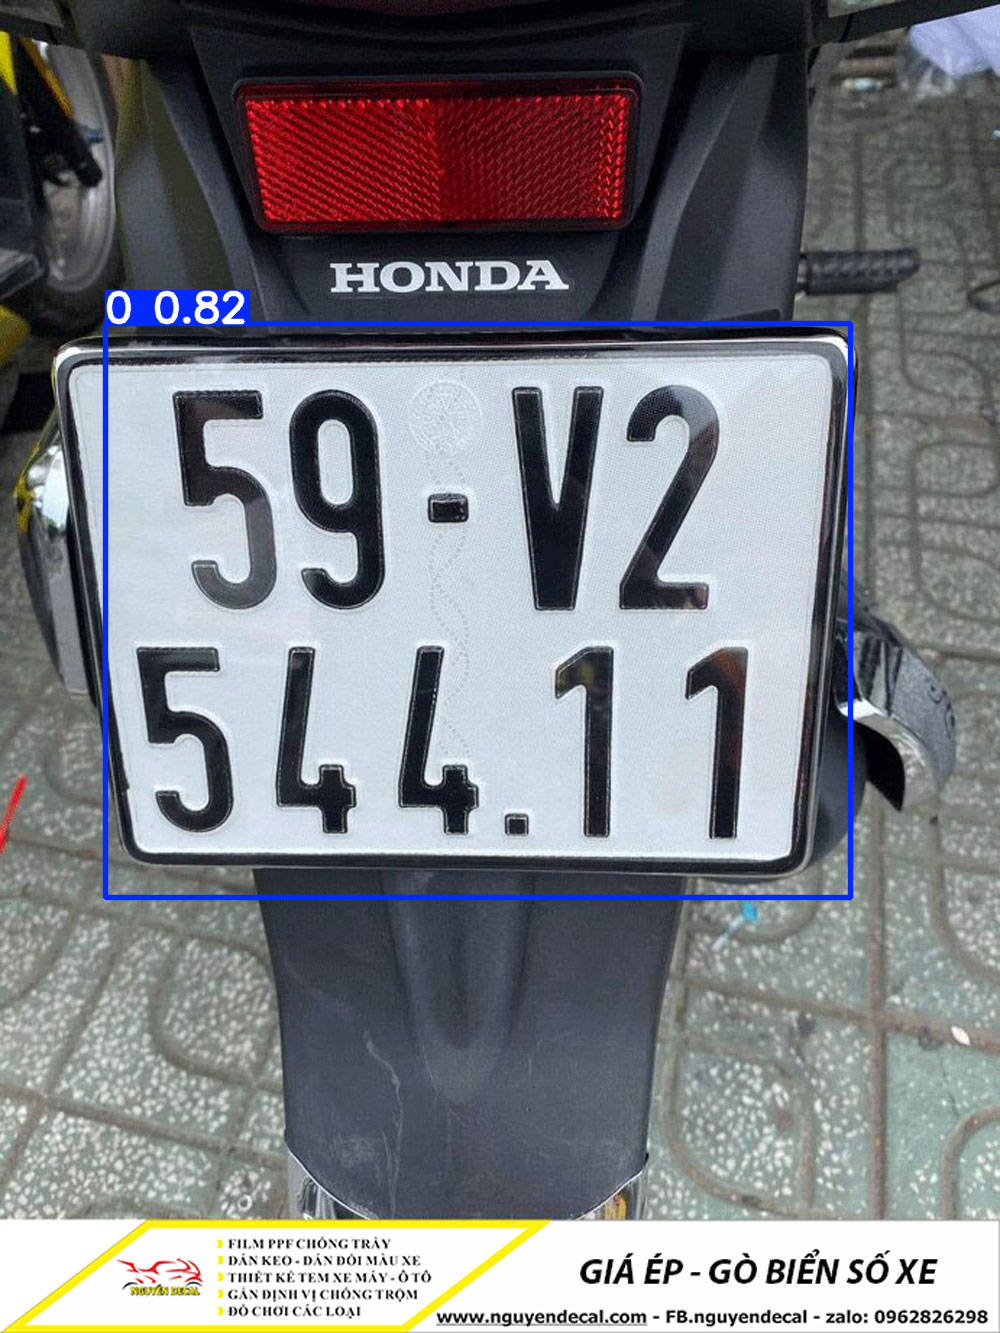

------------------------------
ĐÃ TÌM THẤY BIỂN SỐ!
Tọa độ cắt ảnh (x1, y1, x2, y2): [105.7801513671875, 323.9410705566406, 850.2899780273438, 897.8024291992188]
Độ tin cậy (Confidence): 0.8229179382324219


In [4]:
from ultralytics import YOLO
from PIL import Image

# 1. Load "bộ não" tốt nhất mà bạn vừa train xong
model = YOLO('/content/runs/detect/nhandien_bienso_vn/weights/best.pt')

# 2. Đưa bức ảnh test.jpg vào để mô hình nhận diện
results = model('test.jpg')

# 3. Xử lý và hiển thị kết quả
for r in results:
    # Lấy ảnh đã được AI tự động vẽ khung Bounding Box
    im_array = r.plot()
    # Chuyển đổi hệ màu chuẩn để hiển thị trên Colab
    im = Image.fromarray(im_array[..., ::-1])
    display(im) # Show ảnh ra màn hình

    # In tọa độ ra để báo cáo cho team
    print("-" * 30)
    if len(r.boxes) > 0:
        print("ĐÃ TÌM THẤY BIỂN SỐ!")
        print("Tọa độ cắt ảnh (x1, y1, x2, y2):", r.boxes.xyxy[0].tolist())
        print("Độ tin cậy (Confidence):", r.boxes.conf[0].item())
    else:
        print("Mô hình không thấy biển số nào trong ảnh này.")

Tọa độ khung xanh: [105 323 850 897]


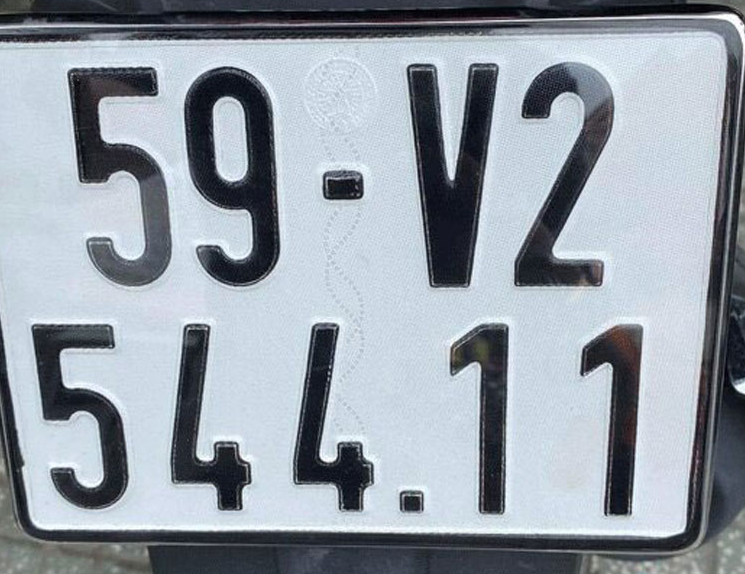

True

In [6]:
import cv2
from google.colab.patches import cv2_imshow # Dùng hàm này để show ảnh trên Colab

# 1. Đọc bức ảnh gốc
img = cv2.imread('test.jpg')

# 2. Lấy tọa độ (x1, y1, x2, y2) từ kết quả nhận diện của YOLO ở ô code trước
# Lấy phần tử đầu tiên [0], đẩy về CPU và ép kiểu thành số nguyên (int) để làm tọa độ pixel
box = results[0].boxes.xyxy[0].cpu().numpy().astype(int)
x1, y1, x2, y2 = box

# 3. DÙNG KÉO CẮT ẢNH (Theo nguyên tắc mảng của Python: [từ_y_đến_y, từ_x_đến_x])
bien_so_cat_duoc = img[y1:y2, x1:x2]

# 4. Hiển thị thành quả
print("Tọa độ khung xanh:", box)
cv2_imshow(bien_so_cat_duoc)

# (Tùy chọn) Lưu cái ảnh nhỏ này lại thành file mới
cv2.imwrite('bien_so_crop.jpg', bien_so_cat_duoc)

In [7]:
!pip install easyocr

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 48.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 kB 21.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 978.2/978.2 kB 77.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.6/300.6 kB 39.5 MB/s eta 0:00:00


In [9]:
import easyocr

# 1. Khởi tạo bộ đọc (Hỗ trợ đọc tiếng Anh và tiếng Việt để nhận diện tốt biển số)
print("Đang tải mô hình ngôn ngữ, đợi một chút nhé...")
reader = easyocr.Reader(['vi', 'en'], gpu=True) # Dùng GPU để đọc siêu tốc

# 2. Đọc chữ từ bức ảnh biển số đã cắt
# (Sử dụng file 'bien_so_crop.jpg' bạn đã lưu ở ô code trước)
ket_qua = reader.readtext('bien_so_crop.jpg')

# 3. In kết quả ra màn hình
print("\n--- KẾT QUẢ ĐỌC BIỂN SỐ ---")
bien_so_hoan_chinh = ""

for (toado_chu, text, do_tin_cay) in ket_qua:
    print(f"Phát hiện dòng: '{text}' | Độ tin cậy: {do_tin_cay:.2f}")

    # Nối các dòng lại với nhau, loại bỏ khoảng trắng và các ký tự đặc biệt (nếu có)
    chuoi_sach = "".join(e for e in text if e.isalnum())
    bien_so_hoan_chinh += chuoi_sach + "-"

# In ra chuỗi text cuối cùng để đưa vào cơ sở dữ liệu
print("-" * 30)
print(f" BIỂN SỐ CUỐI CÙNG: {bien_so_hoan_chinh.strip('-')} ")

Đang tải mô hình ngôn ngữ, đợi một chút nhé...

--- KẾT QUẢ ĐỌC BIỂN SỐ ---
Phát hiện dòng: '59' | Độ tin cậy: 1.00
Phát hiện dòng: 'V2' | Độ tin cậy: 0.27
Phát hiện dòng: '544.11' | Độ tin cậy: 0.86
------------------------------
 BIỂN SỐ CUỐI CÙNG: 59-V2-54411 
